In [1]:
import parselmouth
import matplotlib.pyplot as plt
from audiochains.streams import StreamFromFile
from audiochains.block_methods import UnpackRawInFloat32
import numpy as np
import time as t  # Переименование модуля time

from kiwisolver import strength

Код выполняется!
Частота дискретизации: 16000 Гц
Среднее время обработки одного блока (1024 сэмплов): 0.000182 секунд


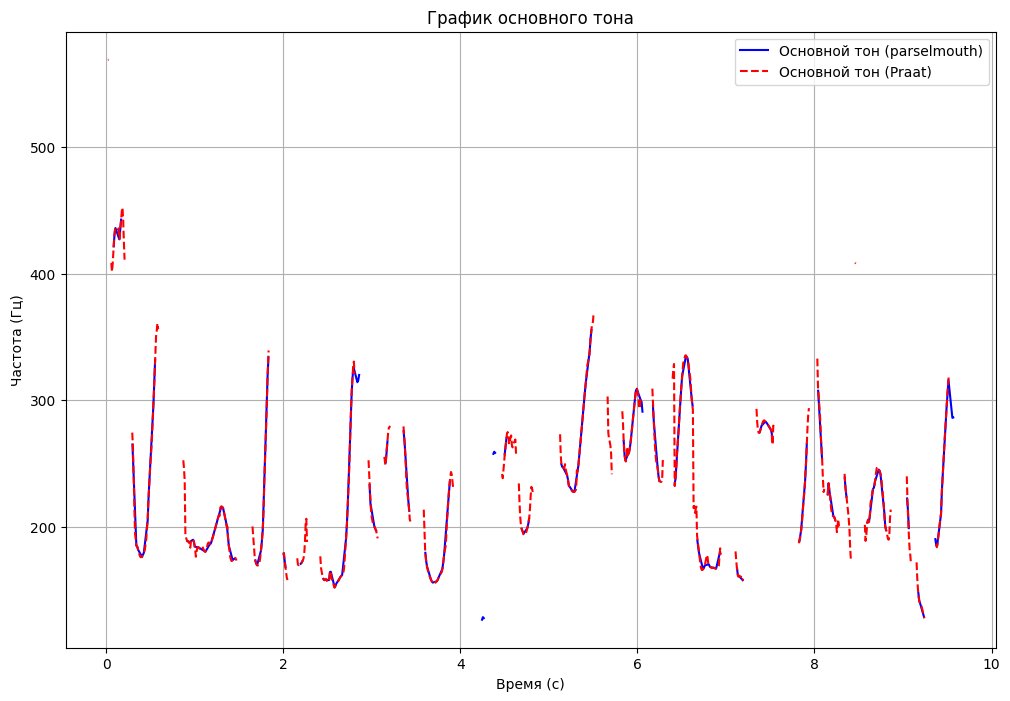

In [9]:
from kiwisolver import strength

audio_file = 'silero_vad/files/femalechist2.wav'
praat_file = 'silero_vad/files/prfm2log.txt'
threshold = 0.5
blocksize = 1024
sampwidth = 2
pitch_floor = 75
pitch_ceiling = 600



print("Код выполняется!")

times = []
frequencies = []
processing_times = []  # Для хранения времени обработки каждого блока

# Чтение значений из praat2.txt
praat_times = []
praat_frequencies = []
try:
    with open(praat_file, 'r') as f:
        next(f)  # Пропускаем заголовок
        for line in f:
            time, freq = line.strip().split()
            time = float(time)
            freq = float(freq) if freq != '--undefined--' else np.nan
            praat_times.append(time)
            praat_frequencies.append(freq)
except Exception as e:
    print(f"Ошибка при чтении файла {praat_file}: {e}")

with StreamFromFile(
    filename=audio_file,
    blocksize=blocksize
) as stream:

    print(f"Частота дискретизации: {stream.samplerate} Гц")

    stream.set_methods(UnpackRawInFloat32())

    current_time = 0
    for i in range(stream.get_iterations()):
        try:
            raw_data = stream.read(blocksize)

            if not raw_data:
                print(f"Блок {i} пустой, пропускаем...")
                continue

            # Измеряем время начала обработки
            start_time = t.time()

            signal = stream.chain_of_methods(raw_data)
            sound = parselmouth.Sound(values=signal, sampling_frequency=stream.samplerate)
            

            #pitch = sound.to_pitch_ac(pitch_floor=pitch_floor, pitch_ceiling=pitch_ceiling)
            pitch = sound.to_pitch_ac(
                time_step=0.01,  # Временной шаг анализа
                pitch_floor=pitch_floor,  # Нижняя граница частоты
                pitch_ceiling=pitch_ceiling,  # Верхняя граница частоты
                silence_threshold=0.35,  # Порог тишины
                voicing_threshold=0.55,  # Порог озвучивания
                octave_cost=0.01,  # Цена отклонения на октаву
                octave_jump_cost=0.35,  # Цена скачка на октаву
                voiced_unvoiced_cost=0.14  # Цена перехода между "озвученным" и "неозвученным"
            )

            frequency = pitch.selected_array['frequency']
            #frequency = frequency * 2
            frequency[frequency == 0] = np.nan
            #strength=pitch.selected_array['strength']
            #strength[strength == 0] = np.nan

            times.extend(current_time + pitch.xs())
            frequencies.extend(frequency)

            current_time += blocksize / stream.samplerate

            # Измеряем время окончания обработки и рассчитываем разницу
            end_time = t.time()
            processing_times.append(end_time - start_time)

        except Exception as err:
            print(f"Ошибка при обработке блока {i}: {err}")

# Вычисление среднего времени обработки одного блока
if processing_times:
    avg_processing_time = sum(processing_times) / len(processing_times)
    print(f"Среднее время обработки одного блока ({blocksize} сэмплов): {avg_processing_time:.6f} секунд")
else:
    print("Обработка не производилась, данные отсутствуют.")

# Построение графика
if times and frequencies:
    plt.figure(figsize=(12, 8))
    plt.plot(times, frequencies, label="Основной тон (parselmouth)", color="blue")

    if praat_times and praat_frequencies:
        plt.plot(praat_times, praat_frequencies, label="Основной тон (Praat)", color="red", linestyle="--")

    plt.xlabel("Время (с)")
    plt.ylabel("Частота (Гц)")
    plt.title("График основного тона")
    plt.legend()
    plt.grid()
    plt.show()

else:
    print("Данные для построения графика отсутствуют.")

# plt.figure(figsize=(12,8))
# plt.plot(times, strength, label ="Сила звука", color="green")
# plt.xlabel("Время (с)")
# plt.ylabel("Сила (дБ)")
# plt.title("График силы")
# plt.legend()
# plt.grid()
# plt.show()

